In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

## Creating the toy dataset

In [2]:
df = pl.scan_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/source/train_df.parquet')

In [17]:
df = df.filter(pl.col('source_user_type').is_in(['human', 'machine']))

In [10]:
source_users = df.select('source_user@domain').unique().collect()

In [11]:
toy_dataset_users = source_users.sample(n=1000)

In [ ]:
df = df.select('time', 'source_user@domain').collect()

In [13]:
toy_dataset = df.join(toy_dataset_users, on='source_user@domain', how='semi')

In [22]:
toy_dataset = toy_dataset.sort(['source_user@domain', 'time'])
toy_dataset.write_parquet(f'/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/toy_dataset.parquet',
                compression="lz4", statistics=True, row_group_size=250_000)

## Checking for independence after smoothing

In [3]:
df = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/toy_dataset.parquet')

/tmp/ipykernel_2262754/2443867103.py:55: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  acfs.append(np.divide((a * b).sum(axis=1), denom, where=denom != 0))


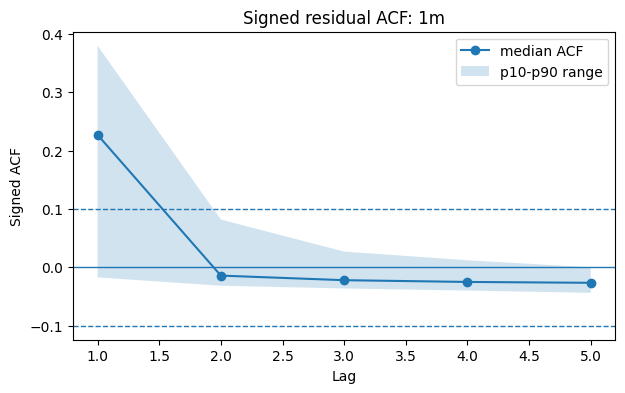

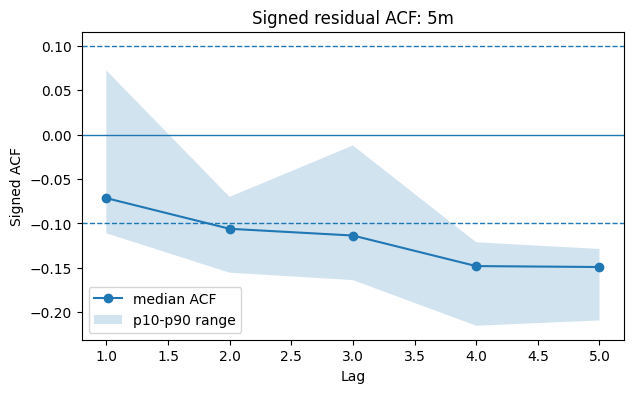

In [4]:
USER = "source_user@domain"
TIME = "time"

bins = {"1m": 60, "5m": 300}
lags = np.arange(1, 6)

d = df.select([
    USER,
    pl.col(TIME).dt.total_seconds().cast(pl.Int64).alias("t")
]).drop_nulls()


def make_matrix(width):
    e = d.with_columns((pl.col("t") // width).alias("b"))

    users = e.select(USER).unique().with_row_index("u")
    b0, b1 = e.select(
        pl.col("b").min().alias("b0"),
        pl.col("b").max().alias("b1"),
    ).row(0)
    counts = (
        e.group_by([USER, "b"])
        .len()
        .join(users, on=USER)
        .with_columns((pl.col("b") - b0).alias("j"))
        .select("u", "j", "len")
        .to_numpy()
    )

    x = np.zeros((users.height, int(b1 - b0 + 1)), dtype=float)
    x[counts[:, 0].astype(int), counts[:, 1].astype(int)] = counts[:, 2]
    return x


for label, width in bins.items():
    x = make_matrix(width)

    # Smooth over 60 minutes
    w = max(1, 3600 // width)
    kernel = np.ones(w) / w
    smooth = np.vstack([
        np.convolve(row, kernel, mode="same")
        for row in x
    ])

    r = x - smooth

    acfs = []
    for lag in lags:
        a, b = r[:, lag:], r[:, :-lag]
        a = a - a.mean(axis=1, keepdims=True)
        b = b - b.mean(axis=1, keepdims=True)

        denom = np.sqrt((a * a).sum(axis=1) * (b * b).sum(axis=1))
        acfs.append(np.divide((a * b).sum(axis=1), denom, where=denom != 0))

    acfs = np.array(acfs)

    med = np.nanmedian(acfs, axis=1)
    p10 = np.nanpercentile(acfs, 10, axis=1)
    p90 = np.nanpercentile(acfs, 90, axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.plot(lags, med, marker="o", label="median ACF")
    ax.fill_between(lags, p10, p90, alpha=0.2, label="p10-p90 range")
    ax.axhline(0, linewidth=1)
    ax.axhline(0.1, linestyle="--", linewidth=1)
    ax.axhline(-0.1, linestyle="--", linewidth=1)

    ax.set(
        xlabel="Lag",
        ylabel="Signed ACF",
        title=f"Signed residual ACF: {label}",
    )

    ax.legend()
    plt.show()

## Checking for degenerate bins and counts

In [3]:
df = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/toy_dataset.parquet')

In [7]:
df.shape[0]

14026121

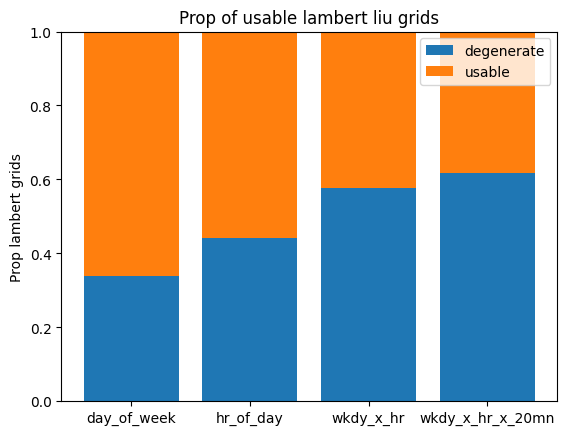

In [ ]:
df = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/toy_dataset.parquet')
sec_in_day = 24 * 60 * 60

df = df.with_columns(pl.col('time').dt.total_seconds().alias('t_sec'))
df = df.select(['source_user@domain', 't_sec']).with_columns([
        ((pl.col('t_sec')//sec_in_day) % 7).alias('wkdy'),
        ((pl.col('t_sec') % sec_in_day)//3600).alias('hr'),
        ((pl.col('t_sec') % 3600)//(20*60)).alias('20_mn')])

# How many items in each grid
grid_specs = {
    'day_of_week': (['wkdy'], 7),
    'hr_of_day': (['hr'], 24),
    'wkdy_x_hr': (['wkdy', 'hr'], 7 * 24),
    'wkdy_x_hr_x_20mn': (['wkdy', 'hr', '20_mn'], 7 * 24 * 3)}

# Total number of users
n_users = df.select('source_user@domain').n_unique()

# Collecting grid names the prop usable and prop degenerate
labels = []
usable_props = []
degen_props = []

for grid_name, (grid_cols, cells_per_user) in grid_specs.items():

    # Getting the total number of non_degen cells and the prop usable
    total_cells = n_users*cells_per_user
    non_degen = df.select(['source_user@domain', *grid_cols]).unique()
    non_degen = non_degen.shape[0]
    prop_usable = non_degen/total_cells

    # Storing to our output lists for plotting
    labels.append(grid_name)
    usable_props.append(prop_usable)
    degen_props.append(1-prop_usable)

# Creating a stacked bar plot
x = np.arange(len(labels))
plt.bar(x, degen_props, label='degenerate')
plt.bar(x, usable_props, bottom=degen_props, label='usable')
plt.xticks(x, labels= labels)
plt.ylim(0, 1)
plt.ylabel('Prop lambert grids')
plt.title('Prop of usable lambert liu grids')
plt.legend()
plt.show()

## Running lambert liu on the toy dataset

In [1]:
df = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/toy_dataset.parquet')

NameError: name 'pl' is not defined

In [2]:
df_init = df.filter(pl.col('time') < pl.duration(days=7))
df_online = df.filter(pl.col('time') >= pl.duration(days=7))

NameError: name 'df' is not defined

In [3]:
# Functions for calculating initiial values of mu and lambda
def create_bins_and_counts(df, param_bin_width, evnt_bin_width):
    '''
    df : The dataframe to augment
    param_bin_width : parameter bin width is the bin width used for calculating the mean and variance lambert liu parameters
    evnt_bin_width : event bin width is the bin width used for grouping oberservations into events 

    returns a df with new columns
        param_bin_id
        param_bin_class
        param_bin_cnt

        envt_bin_id
        evnt_bin_class
        evnt_bin_count
    '''

    #### Adding parameter bin columns
    param_bins_per_week = int(24*60*7/param_bin_width)

    # Creating a bin id column for parameter bins
    df = df.with_columns((pl.col('time').dt.total_minutes()//param_bin_width).alias('param_bin_id'))
    # Creating a bin class which is the same for the same bin on different days i.e. 2 - 2:20 pm on monday different weeks will have the same class
    df = df.with_columns((pl.col('param_bin_id') % param_bins_per_week).alias('param_bin_class'))


    #### Adding event bin column
    # Creating a bin id column for evemt bins
    df = df.with_columns((pl.col('time').dt.total_minutes()//evnt_bin_width).alias('evnt_bin_id'))
    df = df.group_by(['evnt_bin_id', 'source_user@domain', 'param_bin_class']).agg(pl.len().alias('evnt_bin_count'))

    return df

def create_all_bins(df, param_bin_width, evnt_bin_width):
    '''
    Creates a df with all the bin combinations as currently rows with 0 counts are not labeled as 0 but instead are missing
    '''
    evnt_bins_per_param_bin = int(param_bin_width/evnt_bin_width)
    param_bins_per_week = int(7*24*60/param_bin_width)

    total_evnt_bins = df.select(pl.col('evnt_bin_id').max()).item() + 1


    bins_df = pl.DataFrame({'evnt_bin_id': range(total_evnt_bins)})

    # Assigning to param bins
    bins_df = bins_df.with_columns(
        (pl.col('evnt_bin_id')//evnt_bins_per_param_bin).alias('param_bin_id'))

    # Assigning each param bin to param class
    bins_df = bins_df.with_columns(
        (pl.col('param_bin_id') % param_bins_per_week).alias('param_bin_class'))
    
    return bins_df

def add_num_bins(df, param_bin_width, evnt_bin_width):
    '''
    Calculates how many event bins we have in our dataset 
    Right now we have empty bins as missing rows this creates a df of all the event bins possible
    and assigns them to a parameter bin 
    '''

    bins_df = create_all_bins(df, param_bin_width, evnt_bin_width)

    bins_df = bins_df.group_by('param_bin_class').agg(
        pl.col('evnt_bin_id').n_unique().alias('n_evnt_bins'))
    
    df = df.join(bins_df, on='param_bin_class', how='left')

    return df


def calc_init_mu_lambda(df, param_bin_width, evnt_bin_width):
    ''' 
    Takes a df assigns all observations to event and parameter bins and calculates lambda and mu
    '''

    # Check event bins divide param bins and param bins divide days
    assert param_bin_width % evnt_bin_width == 0
    assert 24*60 % param_bin_width == 0

    # Binning the data
    df = create_bins_and_counts(df, param_bin_width, evnt_bin_width)

    # Calculating the number of event bins per parameter bin
    df = add_num_bins(df, param_bin_width, evnt_bin_width)

    # Adding in a column for parameter bins and event bins
    df = df.group_by(['source_user@domain', 'param_bin_class']).agg(
        pl.col('evnt_bin_count').sum().alias('sigma_a'),
        (pl.col('evnt_bin_count')**2).sum().alias('sigma_a2'),
        pl.col('n_evnt_bins').first().alias('n_evnt_bins')
    )

    # Calculate the mean and sample variance inside each event bin
    df = df.with_columns(
        mu = (pl.col('sigma_a') / pl.col('n_evnt_bins')),
        var = (pl.col('sigma_a2') - (pl.col('sigma_a')**2/pl.col('n_evnt_bins')))/ (pl.col('n_evnt_bins') - 1))
    
    return df 

In [4]:
# we are missing the full user x params grid

# The next step is then to get mu and var online using the lambert and liu proposed update scheme



In [32]:
df_init = calc_init_mu_lambda(df_init, 60, 10)

In [34]:
create_bins_and_counts(df_online, 60, 10)

evnt_bin_id,source_user@domain,param_bin_class,evnt_bin_count
i64,str,i64,u32
5098,"""C14169$@DOM1""",9,26
3364,"""C12951$@DOM1""",56,4
4339,"""C8910$@DOM1""",51,7
1593,"""C1122$@DOM1""",97,53
5141,"""C16926$@DOM1""",16,29
…,…,…,…
5014,"""C6574$@DOM1""",163,4
5304,"""C1861$@DOM1""",44,22
4251,"""C15663$@DOM1""",36,2


In [18]:
df.filter(pl.col('var') < pl.col('mu'))

source_user@domain,param_bin_class,sigma_a,sigma_a2,n_evnt_bins,mu,var
str,i64,u32,u32,u32,f64,f64
"""U15@DOM1""",40,2410,163382,36,66.944444,58.453968
"""U227@DOM1""",126,80,280,30,2.666667,2.298851
"""C5714$@DOM1""",88,2,2,30,0.066667,0.064368
"""U1546@C936""",160,2,2,30,0.066667,0.064368
"""U175@DOM1""",27,2,2,36,0.055556,0.053968
…,…,…,…,…,…,…
"""U6920@DOM1""",8,2,2,36,0.055556,0.053968
"""C5714$@DOM1""",3,2,2,36,0.055556,0.053968
"""U1526@DOM1""",50,5,5,30,0.166667,0.143678


In [ ]:
# 222
df.group_by(['source_user@domain', 'param_bin_class']).agg(
    pl.col('evnt_bin_id').n_unique().alias('uev')
).select('uev').max()

uev
u32
222


In [ ]:
## We need to get the small bin counts then big bin parameter estimates
# We need to calculate lambda and mu seperately


In [ ]:

##!! network service is stil in my toy dataset

### Lambert liu and smoothing

In [1]:
import polars as pl
df = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/toy_dataset_full.parquet')

In [2]:
df.head()

time,source_user@domain
duration[μs],str
4m 4s,"""C1$@DOM1"""
4m 14s,"""C1$@DOM1"""
4m 16s,"""C1$@DOM1"""
4m 20s,"""C1$@DOM1"""
19m 4s,"""C1$@DOM1"""


# Start of correct implementation here

In [1]:
config_dict = {
    # Binning configs
    'fine_bin_mins' : 5,
    'coarse_bin_mins' : 60,

    # Train, burn in, test validation split config
    'train_days' : 7,
    'burn_in_days' : 7,
    'validation_days' : 7,
    'test_days' : 7,
    
    # Min Params
    'mean_min' : 1e-8,
    'var_min' : 1e-8,
    'min_mean_var_diff' : 1e-8}

import numpy as np 

In [2]:
# Helper functions outputing dicitonaries
def get_bin_metrics(config_dict=config_dict):
    ''' 
    Returns a dictionary containing all information needed about bin length these numbers are needed throughout the pipeline
    '''
    # Check that bin length divides number of days
    assert 24 * 60 % config_dict['fine_bin_mins'] == 0
    assert 24 * 60 % config_dict['coarse_bin_mins'] == 0
    assert config_dict['coarse_bin_mins'] % config_dict['fine_bin_mins'] == 0

    output_dict = {'fine_bins_per_day' : 24 * 60 // config_dict['fine_bin_mins']}
    output_dict['fine_bins_per_week'] = output_dict['fine_bins_per_day'] * 7
    output_dict['fine_bins_per_coarse_bin'] = config_dict['coarse_bin_mins'] // config_dict['fine_bin_mins']
    output_dict['coarse_bins_per_week'] = output_dict['fine_bins_per_week'] // output_dict['fine_bins_per_coarse_bin']
    output_dict['fine_bin_seconds'] = config_dict['fine_bin_mins'] * 60 

    return output_dict

def get_train_test_split(config_dict=config_dict):
    ''' 
    Calculates the fine bin index of the train test and validation period start and end
    Returns a dictionary with all this information in
    '''

    fine_bins_per_day = 24 * 60 // config_dict['fine_bin_mins']

    train_bins = fine_bins_per_day * config_dict['train_days']
    burn_in_bins = fine_bins_per_day * config_dict['burn_in_days']
    validation_bins = fine_bins_per_day * config_dict['validation_days']
    test_bins = fine_bins_per_day * config_dict['test_days']

    # Constructing a dict for the output
    output_dict = {'train_start' : 0,
                   'train_end' : train_bins}
    
    output_dict['burn_in_start'] = output_dict['train_end']
    output_dict['burn_in_end'] = output_dict['burn_in_start'] + burn_in_bins

    output_dict['validation_start'] = output_dict['burn_in_end']
    output_dict['validation_end'] = output_dict['validation_start'] + validation_bins

    output_dict['test_start'] = output_dict['validation_end']
    output_dict['test_end'] = output_dict['test_start'] + test_bins
    
    return output_dict
    

In [3]:
train_test_dict = get_train_test_split()
bin_metric_dict = get_bin_metrics()

In [4]:
import polars as pl 

data_path = '/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate'
input_data = 'toy_dataset'
df = pl.scan_parquet(f'{data_path}/{input_data}.parquet')


# Creating functions for storing and reading data
def store_data(data, filename, data_path=data_path):
    if isinstance(data, pl.LazyFrame):
        data.sink_parquet(f'{data_path}/{filename}.parquet')
    elif isinstance(data, np.ndarray):
        np.save(f'{data_path}/{filename}.npy', data)
    elif isinstance(data, pl.DataFrame):
        data.write_parquet(f'{data_path}/{filename}.parquet')
    else:
        raise TypeError('Function doesnt support this data type')
    

def load_data(filename, data_type, data_path=data_path):
    ''' 
    Arguments:
        filename: 
            the saved file name
        data_type: ['lazy', 'np', 'df']
            the type of data we want to load in
    '''
    if data_type == 'lazy':
        data = pl.scan_parquet(f'{data_path}/{filename}.parquet')
    elif data_type == 'np':
        data = np.load(f'{data_path}/{filename}.npy')
    elif data_type == 'df':
        data = pl.read_parquet(f'{data_path}/{filename}.parquet')
    else:
        raise TypeError('Function doesnt support this data type')
    return data

In [5]:
# Creating a fine bin and identifying users with some counts in the bin

df = df.with_columns(time = pl.col('time').dt.total_seconds())
df = df.with_columns(fine_bin_idx = pl.col('time') // bin_metric_dict['fine_bin_seconds'])
pos_counts = df.group_by(['source_user@domain', 'fine_bin_idx']).agg(pl.len().alias('count')).collect()

In [6]:
# Creating a user lookup table and storing it
user_lookup = pos_counts.select('source_user@domain').unique().sort(by='source_user@domain').with_row_index('user_id')
store_data(user_lookup, 'user_lookup')

In [7]:
# Creating a compressed lightweight view of the data where we have enoded the user to make a user id
pos_counts = pos_counts.join(user_lookup, on='source_user@domain', how='inner')
pos_counts = pos_counts.select(['user_id', 'fine_bin_idx', 'count']).sort(['user_id', 'fine_bin_idx'])


In [8]:
# Creating an id for each fine bin pos in the week and creating a course bin grouping for each fine bin

pos_counts = pos_counts.with_columns(fine_bin_pos_in_week = pl.col('fine_bin_idx') % bin_metric_dict['fine_bins_per_week'])
pos_counts = pos_counts.with_columns(
    coarse_bin_idx = pl.col('fine_bin_pos_in_week') // bin_metric_dict['fine_bins_per_coarse_bin'],
    fin_bin_within_coarse_pos = pl.col('fine_bin_pos_in_week') % bin_metric_dict['fine_bins_per_coarse_bin'])

store_data(pos_counts, 'encoded_counts')
encoded_counts = pl.read_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/intermediate/encoded_counts.parquet')

In [9]:
train_df = encoded_counts.filter((pl.col('fine_bin_idx') >= train_test_dict['train_start'])
                                  & (pl.col('fine_bin_idx') < train_test_dict['train_end']))

In [10]:
train_df = train_df.with_columns(count_2 = pl.col('count') ** 2)
train_df = train_df.group_by(['user_id', 'coarse_bin_idx']).agg(pl.sum('count').alias('sum_cnt'), pl.sum('count_2').alias('sum_cnt_2'))

In [11]:
import numpy as np
n_users = user_lookup.shape[0]
n_coarse_bins = bin_metric_dict['coarse_bins_per_week']

# Init a grid of parmeters to use
u_init = np.zeros((n_users, n_coarse_bins))
v_init = np.zeros((n_users, n_coarse_bins))

# Calculating the mu and var denom
def bins_per_coarse_train(config_dict=config_dict, bin_metric_dict=bin_metric_dict):
    ''' 
    Calculates the number of fine bins in the coarse bins in the train data
    Right now we just assert that train is a whole number of weeks and perform a simple computation 
    This funciton can be updated later if train is no longer a whole number of days
    '''
    assert config_dict['train_days'] % 7 == 0
    bins_per_coarse = bin_metric_dict['fine_bins_per_coarse_bin'] * (config_dict['train_days'] // 7)
    return bins_per_coarse

bins_per_coarse = bins_per_coarse_train()

# Extrating the entries to assign and assigning them to the df
entries_to_assign = train_df.select(['user_id', 'coarse_bin_idx']).to_numpy()

u_init[entries_to_assign[:,0], entries_to_assign[:,1]] = train_df['sum_cnt'].to_numpy() / bins_per_coarse
v_init[entries_to_assign[:,0], entries_to_assign[:,1]] = (train_df['sum_cnt_2'].to_numpy() - 
                                                          ((train_df['sum_cnt'] **2) / bins_per_coarse))/(bins_per_coarse - 1)

# Capping the min values of u_init and v_init
u_init = np.maximum(u_init, config_dict['mean_min'])
v_init = np.maximum(v_init, config_dict['var_min'])

In [12]:
def get_interpolation_weights(bin_metric_dict=bin_metric_dict):
    '''
    A function that returns the weights we apply when interpolating.
    To understand the computation steps see pages 11 and 12 of lambert liu
    returns:
        weights a numpy array which will be applied as w-1 U-1 + w0 U0 + w1 U1
        the weights array has a row for every fine bin in the coarse bin and 3 columns where each column is the weight being applies to Uis
    '''

    # Getting the m (fine bin number, q and r (defined in lambert liu))
    M = bin_metric_dict['fine_bins_per_coarse_bin']
    m = np.arange(1, M+1)
    q = (m - 1)/M
    r = m/M

    # Getting the two terms used in all calculations
    term_1 = r**2 + r*q + q**2
    term_2 = r + q

    # Computing the weights using the lambert and liu formula
    # these come from rearranging the fomula at the top of page 12 for U-1 U0 and U1
    weights = np.zeros((M, 3))

    weights[:, 0] = term_1/6 - term_2/2 + 1/3
    weights[:, 1] = -term_1/3 + term_2/2 + 5/6
    weights[:, 2] = term_1/ 6 - 1/6

    return weights

weights = get_interpolation_weights()

store_data(weights, filename='interp_weights')
store_data(u_init, filename='u_init')
store_data(v_init, filename='v_init')


In [13]:
# Converting columns to numpy for use by the numba runner
user_id_np = encoded_counts["user_id"].to_numpy().astype(np.int64)
fine_bin_idx_np = encoded_counts["fine_bin_idx"].to_numpy().astype(np.int64)
count_np = encoded_counts["count"].to_numpy().astype(np.int64)

In [14]:
# Creating a lookup table for numba for the first and last entry of users 
user_interactions = encoded_counts.with_row_index().group_by('user_id').agg(
    user_first_index = pl.min('index'),
    user_last_index = pl.max('index')).sort(by='user_id')

user_first_int = user_interactions['user_first_index'].to_numpy().astype(np.int64)
user_last_int = user_interactions['user_last_index'].to_numpy().astype(np.int64)
user_ids = user_interactions['user_id'].to_numpy().astype(np.int64)

assert len(user_ids) == len(user_last_int) == len(user_first_int)

# Saving arrays
store_data(user_ids, 'user_ids')
store_data(user_first_int, 'user_first_int')
store_data(user_last_int, 'user_last_int')


In [15]:
def make_raw_model():
    '''
    Creates a dictionary with the model config to be used by the numba runner
    '''
    n_users, n_coarse_bins = u_init.shape
    # Creating a model dict with dummy placeholders for the cluster mean as no smoothing is done for this model
    # There is 1 cluster so cluster mean vectors have first dim 1
    output = {'name' : 'raw_model',
              'cluster_mean_u' : np.zeros((1,n_coarse_bins), dtype='float64'),
              'cluster_mean_v' : np.zeros((1,n_coarse_bins), dtype='float64'),
              'smoothing_parameter' : 0,
              'cluster_assignments' : np.zeros(n_users, dtype='int64')
              }
    
    return output

raw_model = make_raw_model()

In [16]:
### Creating clusters and then initialising a cluster model

from sklearn.cluster import KMeans

#! NOTE right now this clustering doesnt work very well assigning most users to cluster 0 and very few users to the other clusters. 
#! We will work on clustering down the line and check if this will be resolved when we filter out the 0 users

#! NOTE also we should probably cluster the data based on the parameters for the full training data not just for the first week of train

def get_k_means_assignments(k, random_state, vec_to_cluster=u_init):
    '''
    Performs k means clustering on a numpy array and returns a vector of cluster assignments
    '''

    k_means_cluster = KMeans(n_clusters=k, random_state=random_state)
    clusters = k_means_cluster.fit_predict(vec_to_cluster).astype(np.int64)

    return clusters

def get_clustering_means(cluster_groups, u_init=u_init, v_init=v_init):
    ''' 
    Calculates mean u and v values for each cluster group and each time bin
    Args:
        cluster_groups a n_users length vector of cluster assignments
        u_init : the calculated vector of parameter means
        v_init : the calculated vector of initial parameter variances
    '''

    n_users, n_coarse_bins = u_init.shape 
    n_clusters = cluster_groups.max() + 1
    print(f'Number of clusters identified : {n_clusters}')

    # Init mean vectors
    cluster_mean_u = np.zeros((n_clusters, n_coarse_bins), dtype='float64')
    cluster_mean_v = np.zeros((n_clusters, n_coarse_bins), dtype='float64')
    users_per_cluster = np.zeros(n_clusters, dtype='float64')

    # Summing u and v contributions in each cluster
    # Extract the cluster assignment for each user and then add their parameters to each bin
    for user_id in range(n_users):
        cluster_assignment = int(cluster_groups[user_id])
        cluster_mean_u[cluster_assignment, :] += u_init[user_id, :]
        cluster_mean_v[cluster_assignment, :] += v_init[user_id, :]
        users_per_cluster[cluster_assignment] += 1

    # Dividing through to get the averages in each cluster
    for cluster_assignment in range(n_clusters):
        if users_per_cluster[cluster_assignment] > 0:
            cluster_mean_u[cluster_assignment, :] /= users_per_cluster[cluster_assignment]
            cluster_mean_v[cluster_assignment, :] /= users_per_cluster[cluster_assignment]

    return cluster_mean_u, cluster_mean_v


def make_cluster_model(algo_name, cluster_assignments, smoothing_parameter, u_init=u_init, v_init=v_init):

    cluster_mean_u, cluster_mean_v = get_clustering_means(u_init=u_init, v_init=v_init, cluster_groups=cluster_assignments)

    output = {'name' : f'{algo_name}_clustering_model',
              'cluster_mean_u' : cluster_mean_u,
              'cluster_mean_v' : cluster_mean_v,
              'smoothing_parameter' : smoothing_parameter,
              'cluster_assignments' : cluster_assignments}

    return output 

# running these functions
k_means_assignments = get_k_means_assignments(k=4, random_state=10)
clustering_model = make_cluster_model(algo_name='k_means', 
                                    cluster_assignments=k_means_assignments,
                                    smoothing_parameter=0.5)



Number of clusters identified : 4


In [17]:
# Loading in the data needed for the next stage
interp_weights = load_data('interp_weights', data_type='np')
user_first_int = load_data('user_first_int', 'np')
user_last_int = load_data('user_last_int', 'np')

### Creating njit functions for the final runner

In [18]:
# Creating functions that get the log pmf value for the negative binomial distribution (or the poisson distirbution for underdispersed users)
from numba import njit
import math 

@njit 
def poisson_lpmf(x, mu):
    ''' 
    Poisson log pmf
    '''
    return x*math.log(mu) - mu - math.lgamma(x+1)

@njit
def neg_bin_lpmf(x, mu, sigma2):
    p = mu/sigma2
    r = (mu*p) / (1-p)
    return math.lgamma(x+r) - math.lgamma(r) - math.lgamma(x+1) + r*math.log(p) + x*math.log(1-p)

@njit 
def get_lmpf_val(x, mu, sigma2, mean_min, var_min, min_mean_var_diff):
    if mu <= 0:
        raise ValueError(' Mu < 0 ')
    if sigma2 <= 0:
        raise ValueError('Sigma^2 , 0')
    
    mu = max(mu, mean_min)
    sigma2 = max(sigma2, var_min)
    if sigma2 <= mu + min_mean_var_diff:
        return poisson_lpmf(x, mu)
    else: 
        return neg_bin_lpmf(x, mu, sigma2)


In [19]:
@njit
def get_time_period(fine_bin_idx, validation_start, validation_end, test_start, test_end):
    ''' 
    Returns:
        2 if we are in the validation data
        3 if we are in the test data
        1 otherwise (train + burn in and any unused data)
    '''
    if validation_start <= fine_bin_idx and fine_bin_idx < validation_end:
        return 2
    elif test_start <= fine_bin_idx and fine_bin_idx < test_end:
        return 3
    else: 
        return 1

In [ ]:
# Creating a function that smooths between users and parameter
@njit 
def smoothing_function(smoothing_strength, user_parameter, cluster_parameter):
    ''' 
    Function used for smoothing between the cluster parameter and the user parameter
    '''
    return (1-smoothing_strength) * user_parameter + smoothing_strength*cluster_parameter

@njit 
def interpolate_values(v_neg_1, v_0, v_1, fine_bin_within_coarse_pos, weights):
    '''
        Applies the quadratic interpolation between the left middle and right bin values
    '''
    # Extract the weights we will use for the interpolation
    w_neg_1, w_0, w_1 = weights[fine_bin_within_coarse_pos]
    return w_neg_1 * v_neg_1 + w_0 * v_0 + w_1 * v_1

@njit 
def smooth_params(user_param_grid, cluster_param_grid, cluster_assignments, smoothing_strength, crnt_user, crnt_coarse_bin,
                  crnt_fine_bin_within_coarse_pos, interpolation_weights):
    ''' 
    Takes a parameter mu or sigma2 and smooths it towards the cluster parameter using `smoothing_function`
    '''
    # Get the cluster assignment for the current user
    cluster_id = cluster_assignments[crnt_user]

    # Get the 3 values to interpolate
    n_coarse_bins = user_param_grid.shape[1]
    neg_1_coarse_bin = (crnt_coarse_bin -1) % n_coarse_bins
    _1_coarse_bin = (crnt_coarse_bin + 1)% n_coarse_bins

    ## Smooth the 3 values we will later interpolate
    v_neg_1 = smoothing_function(smoothing_strength, user_param_grid[crnt_user, neg_1_coarse_bin], cluster_param_grid[cluster_id, crnt_coarse_bin])
    v_0 = smoothing_function(smoothing_strength, user_param_grid[crnt_user, crnt_coarse_bin], cluster_param_grid[cluster_id, crnt_coarse_bin])
    v_1 = smoothing_function(smoothing_strength, user_param_grid[crnt_user, _1_coarse_bin], cluster_param_grid[cluster_id, crnt_coarse_bin])

    # Interpolate the values 
    return interpolate_values(v_neg_1, v_0, v_1, crnt_fine_bin_within_coarse_pos, interpolation_weights)



@njit
def get_smoothed_params(u, v, cluster_u, cluster_v, cluster_assignments, smoothing_strength, crnt_user, crnt_coarse_bin,
                        crnt_fine_bin_within_coarse_pos, smoothing_weights):
    
    mu = smooth_params(u, cluster_u, 
                       cluster_assignments=cluster_assignments, smoothing_strength=smoothing_strength, crnt_user=crnt_user, 
                       crnt_coarse_bin=crnt_coarse_bin, crnt_fine_bin_within_coarse_pos=crnt_fine_bin_within_coarse_pos, smoothing_weights=smoothing_weights)
    
    sigma2 = smooth_params(v, cluster_v, 
                        cluster_assignments=cluster_assignments, smoothing_strength=smoothing_strength, crnt_user=crnt_user, 
                        crnt_coarse_bin=crnt_coarse_bin, crnt_fine_bin_within_coarse_pos=crnt_fine_bin_within_coarse_pos, smoothing_weights=smoothing_weights)

    return mu, sigma2

In [ ]:
# Creating a function that collects grid updates and a function that updates the grid

@njit
def update_grid(u, v, crnt_user_id, new_grid, temp_v_sum):
    ''' 
    Replaces grid values with temporary grid values
    '''
    return 1


@njit
def collect_temp_grid():
    '''
    collects the temp grid as we go along 
    '''
    return 1

In [ ]:
# Function for updating cluster parameters 
@njit 
def get_new_clustering_means(cluster_groups, u, v):
    ''' 
    Calculates mean u and v values for each cluster group and each time bin
    Args:
        cluster_groups a n_users length vector of cluster assignments
        u : the calculated vector of u parameter means
        v : the calculated vector of v parameter variances
    '''

    n_users, n_coarse_bins = u.shape 
    n_clusters = cluster_groups.max() + 1

    # Init mean vectors
    cluster_mean_u = np.zeros((n_clusters, n_coarse_bins), dtype=np.float64)
    cluster_mean_v = np.zeros((n_clusters, n_coarse_bins), dtype=np.float64)
    users_per_cluster = np.zeros(n_clusters, dtype=np.float64)

    # Summing u and v contributions in each cluster
    # Extract the cluster assignment for each user and then add their parameters to each bin
    for user_id in range(n_users):
        cluster_assignment = int(cluster_groups[user_id])
        cluster_mean_u[cluster_assignment, :] += u[user_id, :]
        cluster_mean_v[cluster_assignment, :] += v[user_id, :]
        users_per_cluster[cluster_assignment] += 1

    # Dividing through to get the averages in each cluster
    for cluster_assignment in range(n_clusters):
        if users_per_cluster[cluster_assignment] > 0:
            cluster_mean_u[cluster_assignment, :] /= users_per_cluster[cluster_assignment]
            cluster_mean_v[cluster_assignment, :] /= users_per_cluster[cluster_assignment]

    return cluster_mean_u, cluster_mean_v

In [ ]:
@njit
def run_lambert_liu():
    for user_id in range(n_users):
        u = u_init.copy()
        v = v_init.copy()

        cluster_u = cluster_u_init.copy()
        cluster_v = cluster_v_init.copy()

        n_coarse_bins = u.shape[1]


    for week in range(first_week, last_week):
        week_start = 1
        week_end = 1

        for user_id in range(n_users):

            # Init numpy vectors for calculating the user sums
            temp_u_sum
            temp_v_sum

            for fine_bin_idx in range(week_start, week_end):
                while p 
                get_smoothed_params 

                get_lmpf_val

                get_period_idx

                update_temp_grid

            commit_temp_grid

        recompute_cluster_means

### Now unused functions

In [ ]:
def interpolate_values(values, coarse_bin_idx, fine_bin_within_coarse_pos, weights):
    '''
    Takes either a set of values either U or V for each course bin and produces an 
    interpolated U/V value for the specified fine bin

    Args:
        coarse bin idx : the index of the coarse bin we are currently in
        fine_bin_within_coarse_pos : the position of the fine bin within the coarse bin we are currently in
    '''
    
    # Getting the indicies of the left current and right bins to use
    n_coarse_bins = values.shape[0]
    left_bin_idx = (coarse_bin_idx -1) % n_coarse_bins
    right_bin_idx = (coarse_bin_idx + 1)% n_coarse_bins
    

    # Extract the weights we will use for the interpolation
    w_neg_1, w_0, w_1 = weights[fine_bin_within_coarse_pos]
    output = w_neg_1 * values[left_bin_idx] + w_0 * values[coarse_bin_idx] + w_1 * values[right_bin_idx]

    return output